In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv3.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 5
N_TICKS = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]
W = pd.read_csv('weights(inv only diag).csv').to_numpy()

In [4]:
# метрика лосса: матрица ковариаций
# + байесовское обучение оптуной, все диапазоны были выбраны обще (далее будут сужаться)
def loss_msm(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret", "autocorr_on_ret_1", "autocorr_on_ret_5", "autocorr_on_ret_10", "autocorr_on_abs_1", "autocorr_on_abs_5", "autocorr_on_abs_10"]
    errors = np.zeros((len(num), 1))
    id = -1
    for i in num:
        id += 1
        errors[id] = t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]
    ans = errors.T @ W @ errors
    # print(ans.shape)
    return float(ans[0][0])

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 20, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 3, 50),
        'Chartist': trial.suggest_int('Chartist', 30, 120),
        'Universalist': trial.suggest_int('Universalist', 5, 50),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 0.05, 100, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 0.005, 10, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -4, -1),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 100, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 100, log=True),
        'Exchange_Volume': trial.suggest_int('Exchange_Volume', 1000, 20000)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(volume=params['Exchange_Volume'], std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'])
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, params['Exchange_Volume']) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, params['Exchange_Volume']) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, params['Exchange_Volume']) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, params['Exchange_Volume']) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, params['Exchange_Volume']) for _ in range(0)],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_msm(target_params, model_params))
        except Exception as e:
            print(e)
            continue

    if len(errors) != N_RUNS:
        return 1000
    return float(np.mean(errors))

In [5]:
# само обучение
study = optuna.create_study(study_name="calibration_mse(diff vol)", direction="minimize", storage="sqlite:///calibration_mse(diff vol)",  load_if_exists=True)
study.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study.best_params
best_score = study.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-04-26 13:51:51,825] A new study created in RDB with name: calibration_mse(diff vol)
Best trial: 0. Best value: 92.9591:   0%|          | 1/500 [01:28<12:17:41, 88.70s/it]

[I 2026-04-26 13:53:20,522] Trial 0 finished with value: 92.95907424471962 and parameters: {'Random': 40, 'Fundamentalist': 13, 'Chartist': 60, 'Universalist': 7, 'Transaction_cost': 0.017736597182180524, 'Std': 0.7600065253832949, 'Std_Random': 0.006557814554070419, 'Avg_Traders': -3.0305654586754764, 'Last_Step': 0.7283649241003062, 'Last_Ret': 0.0013052875595889499, 'Noisy_Level': 4.547922206524774, 'Exchange_Volume': 18339}. Best is trial 0 with value: 92.95907424471962.


Best trial: 0. Best value: 92.9591:   0%|          | 2/500 [02:50<11:40:53, 84.45s/it]

[I 2026-04-26 13:54:41,992] Trial 1 finished with value: 1298.239620271324 and parameters: {'Random': 54, 'Fundamentalist': 6, 'Chartist': 107, 'Universalist': 22, 'Transaction_cost': 0.0005583231228566242, 'Std': 0.07294113827960032, 'Std_Random': 0.16003353959372585, 'Avg_Traders': -3.0196632716388687, 'Last_Step': 0.6328792943719794, 'Last_Ret': 24.04521426363856, 'Noisy_Level': 21.44034036935983, 'Exchange_Volume': 13380}. Best is trial 0 with value: 92.95907424471962.


Best trial: 0. Best value: 92.9591:   1%|          | 3/500 [03:03<7:10:07, 51.93s/it] 

...

[I 2026-04-26 17:02:42,876] Trial 497 finished with value: 386.5399461380689 and parameters: {'Random': 68, 'Fundamentalist': 6, 'Chartist': 91, 'Universalist': 8, 'Transaction_cost': 0.0013313455431318744, 'Std': 12.28739696838301, 'Std_Random': 0.3082510509602174, 'Avg_Traders': -2.3839178484321035, 'Last_Step': 0.8203239223139549, 'Last_Ret': 82.23272070327992, 'Noisy_Level': 0.00960723567988338, 'Exchange_Volume': 8440}. Best is trial 470 with value: 7.643332984262464.


Best trial: 470. Best value: 7.64333: 100%|█████████▉| 499/500 [3:11:03<00:13, 13.36s/it]

[I 2026-04-26 17:02:55,083] Trial 498 finished with value: 13.39565773333943 and parameters: {'Random': 69, 'Fundamentalist': 7, 'Chartist': 90, 'Universalist': 9, 'Transaction_cost': 0.0012377778487449092, 'Std': 10.253658959571064, 'Std_Random': 0.3212976283604496, 'Avg_Traders': -2.506332383924406, 'Last_Step': 0.805876535138005, 'Last_Ret': 0.04087167115344316, 'Noisy_Level': 0.009281717191200762, 'Exchange_Volume': 7758}. Best is trial 470 with value: 7.643332984262464.


Best trial: 470. Best value: 7.64333: 100%|██████████| 500/500 [3:11:15<00:00, 22.95s/it]

[I 2026-04-26 17:03:06,874] Trial 499 finished with value: 14.26371291857902 and parameters: {'Random': 71, 'Fundamentalist': 6, 'Chartist': 89, 'Universalist': 7, 'Transaction_cost': 0.0012252507583083397, 'Std': 12.238556872345177, 'Std_Random': 0.38472254170228914, 'Avg_Traders': -2.4753529017554556, 'Last_Step': 0.7825857521476592, 'Last_Ret': 0.06038640770660954, 'Noisy_Level': 0.007281739017392935, 'Exchange_Volume': 8023}. Best is trial 470 with value: 7.643332984262464.
Best params: {'Random': 83, 'Fundamentalist': 7, 'Chartist': 90, 'Universalist': 5, 'Transaction_cost': 0.0009562830284515128, 'Std': 62.632025331871795, 'Std_Random': 0.37564114966073875, 'Avg_Traders': -2.6486759121005514, 'Last_Step': 0.5076823322121735, 'Last_Ret': 0.038178178081154486, 'Noisy_Level': 0.005655157987368508, 'Exchange_Volume': 9932}
Best Score: 7.643332984262464


[I 2026-04-26 18:51:10,032] Using an existing study with name 'calibration_mse(diff vol)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_6028\14244818.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


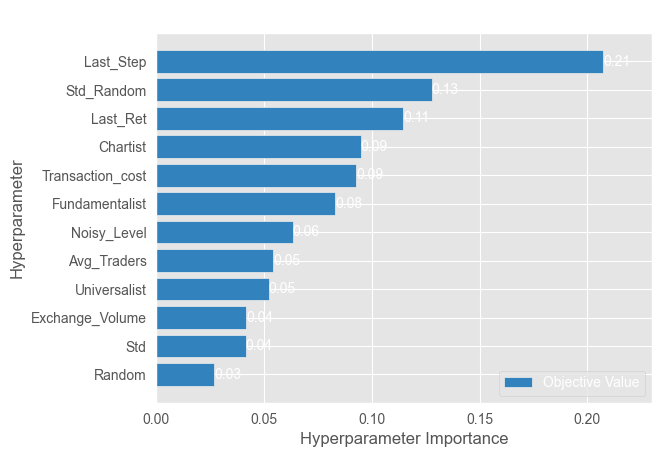

In [6]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study = optuna.create_study(study_name="calibration_mse(diff vol)", direction="minimize", storage="sqlite:///calibration_mse(diff vol)",  load_if_exists=True)
plot_param_importances(study)
plt.show()

C:\Users\rodion\AppData\Local\Temp\ipykernel_6028\2019636087.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


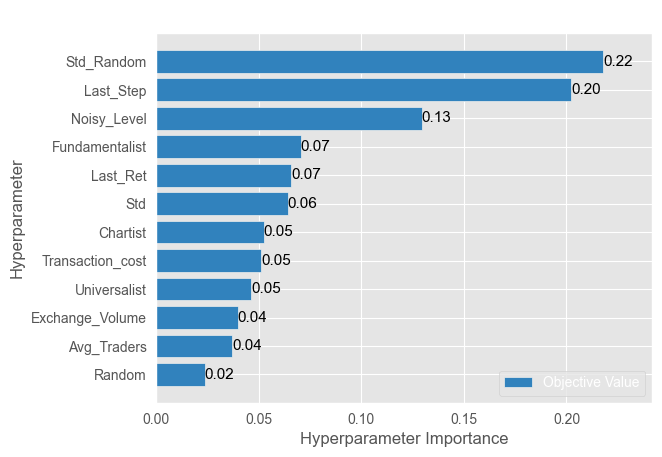

In [7]:
ax = plot_param_importances(study)
for txt in ax.texts:
    txt.set_color("black")   # можно "yellow", "red", "#ffffff" и т.д.
    txt.set_fontsize(11)

plt.show()